# Swarm Data Fusion toolbox demo notebook

**Swarm Data Fusion is a Python tool designed to combine Swarm satellite data with a wide range of ionosphere-thermosphere observations. The goal of SwarmDF is to maximize contextual information around the Swarm satellites for studying local electrodynamics in the high-latitude ionosphere.**


This notebook serves as documentation for the SwarmDF Python module. It guides the reader step by step through a typical SwarmDF run.

Alternatively, users may run swarmDF_GUI.py from a terminal to access a graphical user interface. The GUI is designed to be user-friendly and does not require prior familiarity with the package. It provides the outputs needed for further analysis.

For users who wish to go beyond the GUI, the same analysis can be reproduced by following the steps presented in this notebook.

## Imports

In [7]:
from datetime import datetime
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from IPython.display import Image, display


# from swarmdf.core.swarm_orbit_and_grid import swarm_trajectory
# from swarmdf.core.data_collect import DataManager
# from swarmdf.core.lompe_analysis import run_lompe, lompe_output
# from swarmdf.core.conductance import compute_conductances
# from swarmdf.core.lompeOSSE_analysis import run_lompeOSSE, lompeOSSE_output
from swarmdf import *


## Input

### Main input

Start by choosing a Swarm satellite and defining the time interval for the study.  
This is the only input required before SwarmDF can run. All additional parameters have default values.

In [8]:
sat_id = 'A'
start = datetime(2014, 12, 15, 1, 15, 0)
end   = datetime(2014, 12, 15, 1, 16, 0)
time_step = 30 # [s]

### Datasets


Choose datasets among SuperDARN, SuperMAG, Iridium/Ampere, Swarm electric field and Swarm magnetic field. By default, all datasets are selected. 

In [9]:
datasets2download = ['superdarn', 'supermag', 'iridium_ampere', 'swarm_mag', "swarm_efield", "dmsp_ssies17", "dmsp_ssies18"]

### Grid

Define the extent, spatial resolution, and temporal spacing of the successive 2D regions surrounding the selected Swarm satellite along its trajectory.
Has to be defined as a dictionary.

In [10]:
grid_params = {"L": 1500, # km 
               "W": 2000, # km
               "Lres": 200, # km
               "Wres": 200, # km
               "wshift": 0
              }

### Conductance

! Coductances are a major input for Lompe. 
Define the model of your choice. 

In [11]:
conductance_method = 'Zang & Paxton model'

kp_value = 4
f107_value = 100
background_value = 2 

conductance_params = {"kp": kp_value, "f107": f107_value, "background": background_value}

## Data fusion 

!! 
using sample input datasets
collect swarm data + collect additional data around swarm satellite track within grid + show trajectory and data distribution

The script data_collect.py runs in the background, it checks if the datafiles requested by the user already exist in their data folder, and downloads the files if not. 

SwarmDF will gather Swarm orbit data together with the additional datasets and perform Lompe analyses on those grids, with a default temporal spacing of 30 s between successive grids/analyses.

In [ ]:
######################
# Collect data
######################

# from importlib.resources import files
# data_path = str(files("swarmdf") / "data" / "sample_datasets") + "/"
# print(data_path)

# Fetch and load data
datahandler = DataManager(start, end, datasets2download, demo = False) # Turn demo to True if you want to skip data collection and use sample datasets
datasets = datahandler.datasets

/Users/margot/Docs/Academia/Research/Python/SwarmDF/src/swarmdf/data/sample_datasets/
File already exists
File already exists
⚠️ swarm_efield: dataset is empty


Plot the local grid along the Swarm trajectory as well as the selected data.
A gif is created in the user's folder. 

The swarm_orbit_and_grid.py script ... 

In [13]:
# # Animation speed
# gif_speed= 550 # [ms]

In [14]:
# center_times, grids, data_frames = swarm_trajectory(sat_id, start, end, time_step, grid_params, datasets, gif_speed, show_data=True)

lompe_input = LompeInput(sat_id, start, end, datasets)
grids, analysis_times = lompe_input.build_grids_around_swarm(time_step, grid_params)
data_objects_per_grid = lompe_input.prepare_lompe_input(grids, analysis_times) 

Time interval around Swarm center time (2014-12-15 01:15:20): 2014-12-15 01:13:10 - 2014-12-15 01:17:10
Time interval around Swarm center time (2014-12-15 01:15:50): 2014-12-15 01:13:40 - 2014-12-15 01:17:40
! need to fix Swarm elec function in prepare_data
! need to fix Swarm elec function in prepare_data


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


Figures with Swarm tracks, analysis grid, and data distribution for each time step saved in: /Users/margot/Docs/Academia/Research/Python/SwarmDF/src/outputs/tmp/
GIF saved in outputs directory as: /Users/margot/Docs/Academia/Research/Python/SwarmDF/src/outputs/lompe-input_swarmA.gif


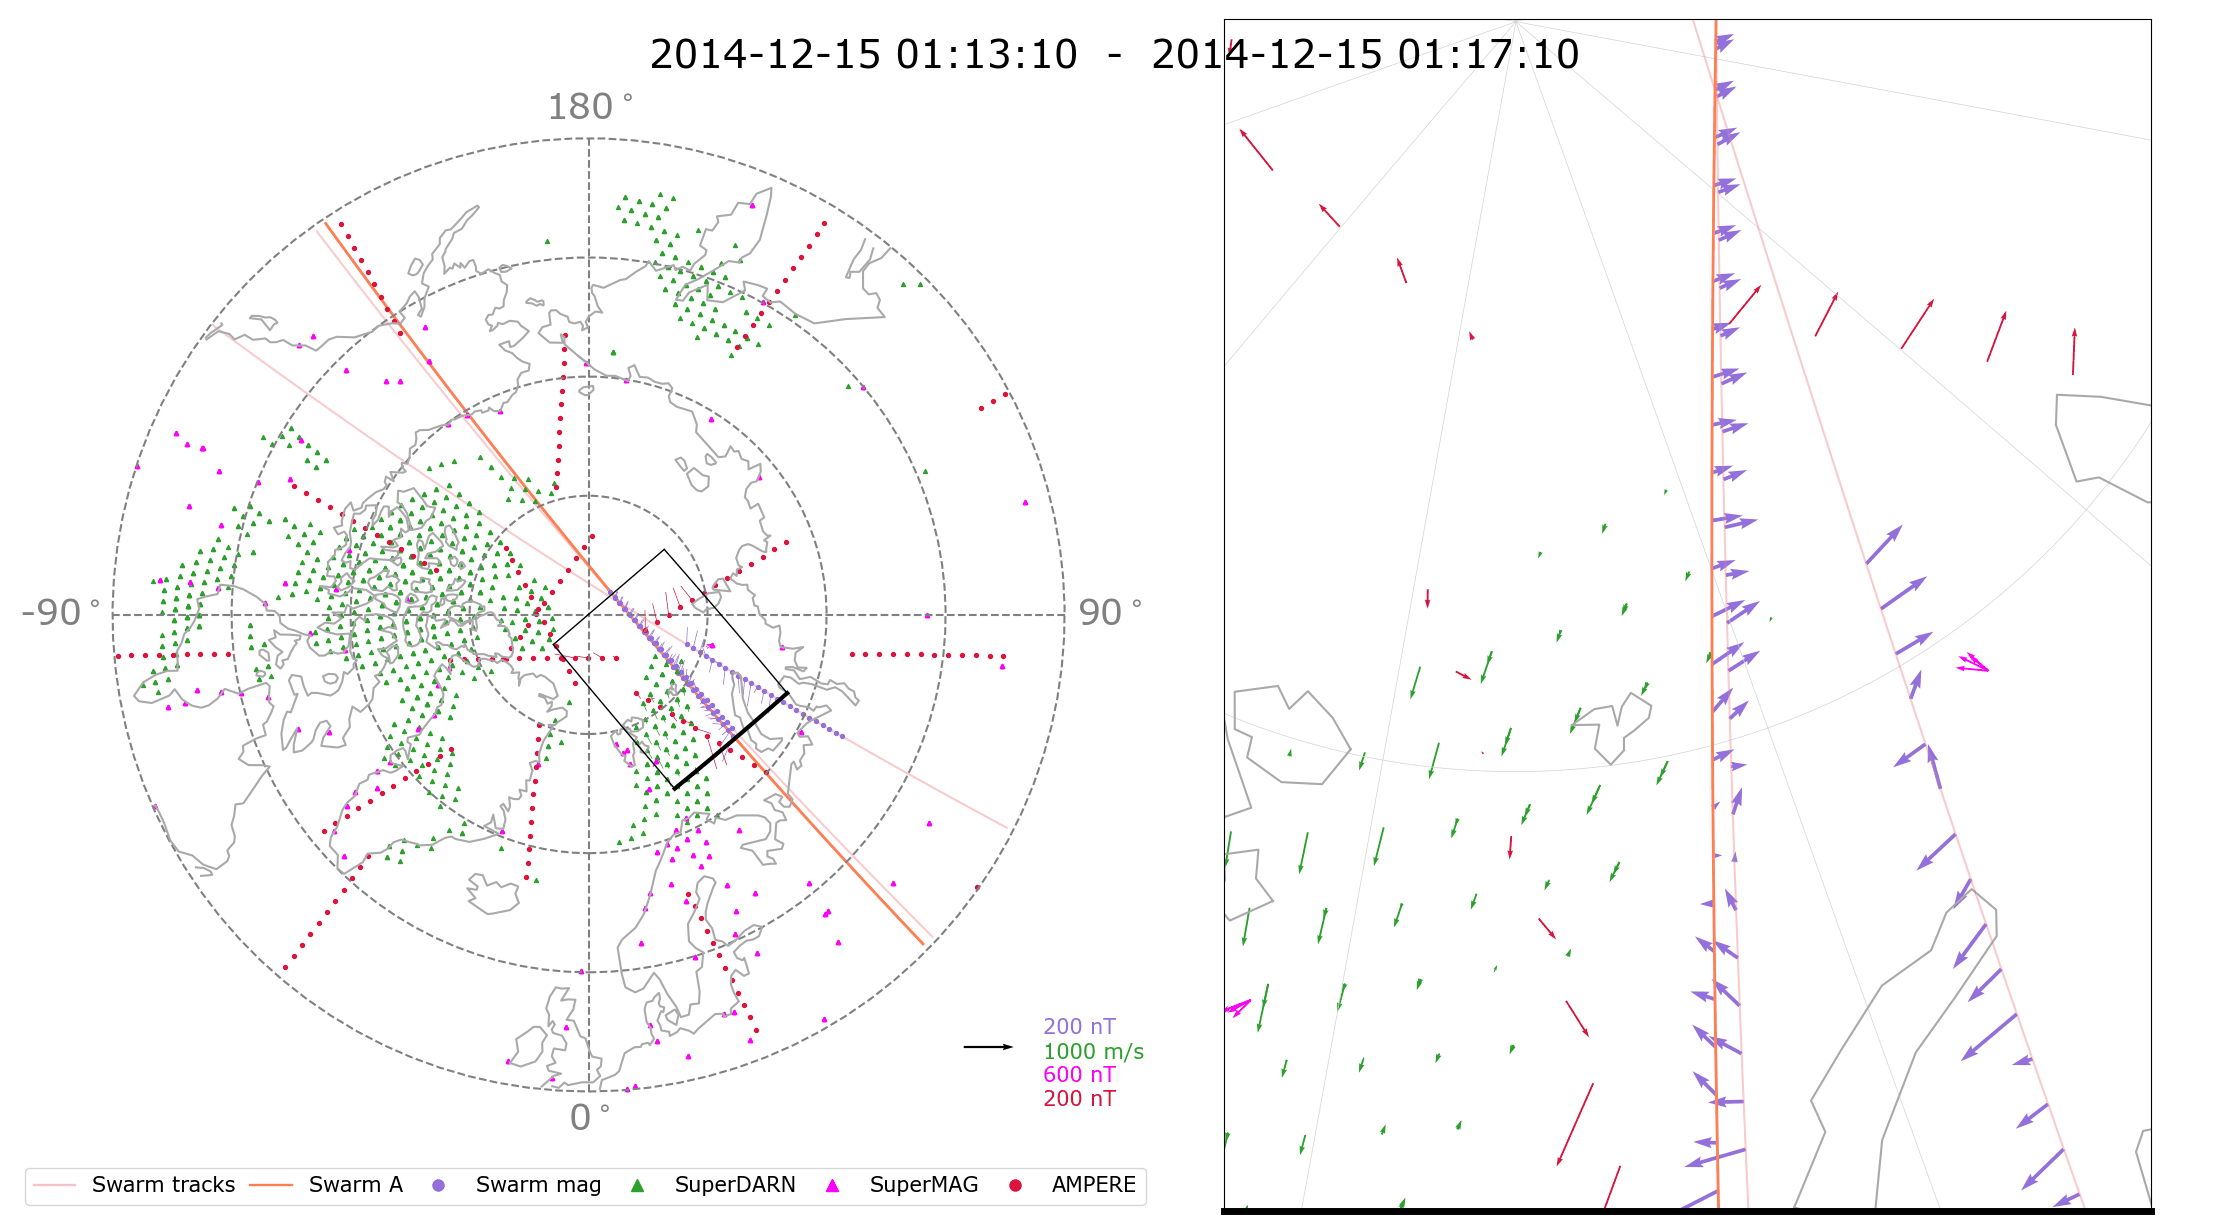

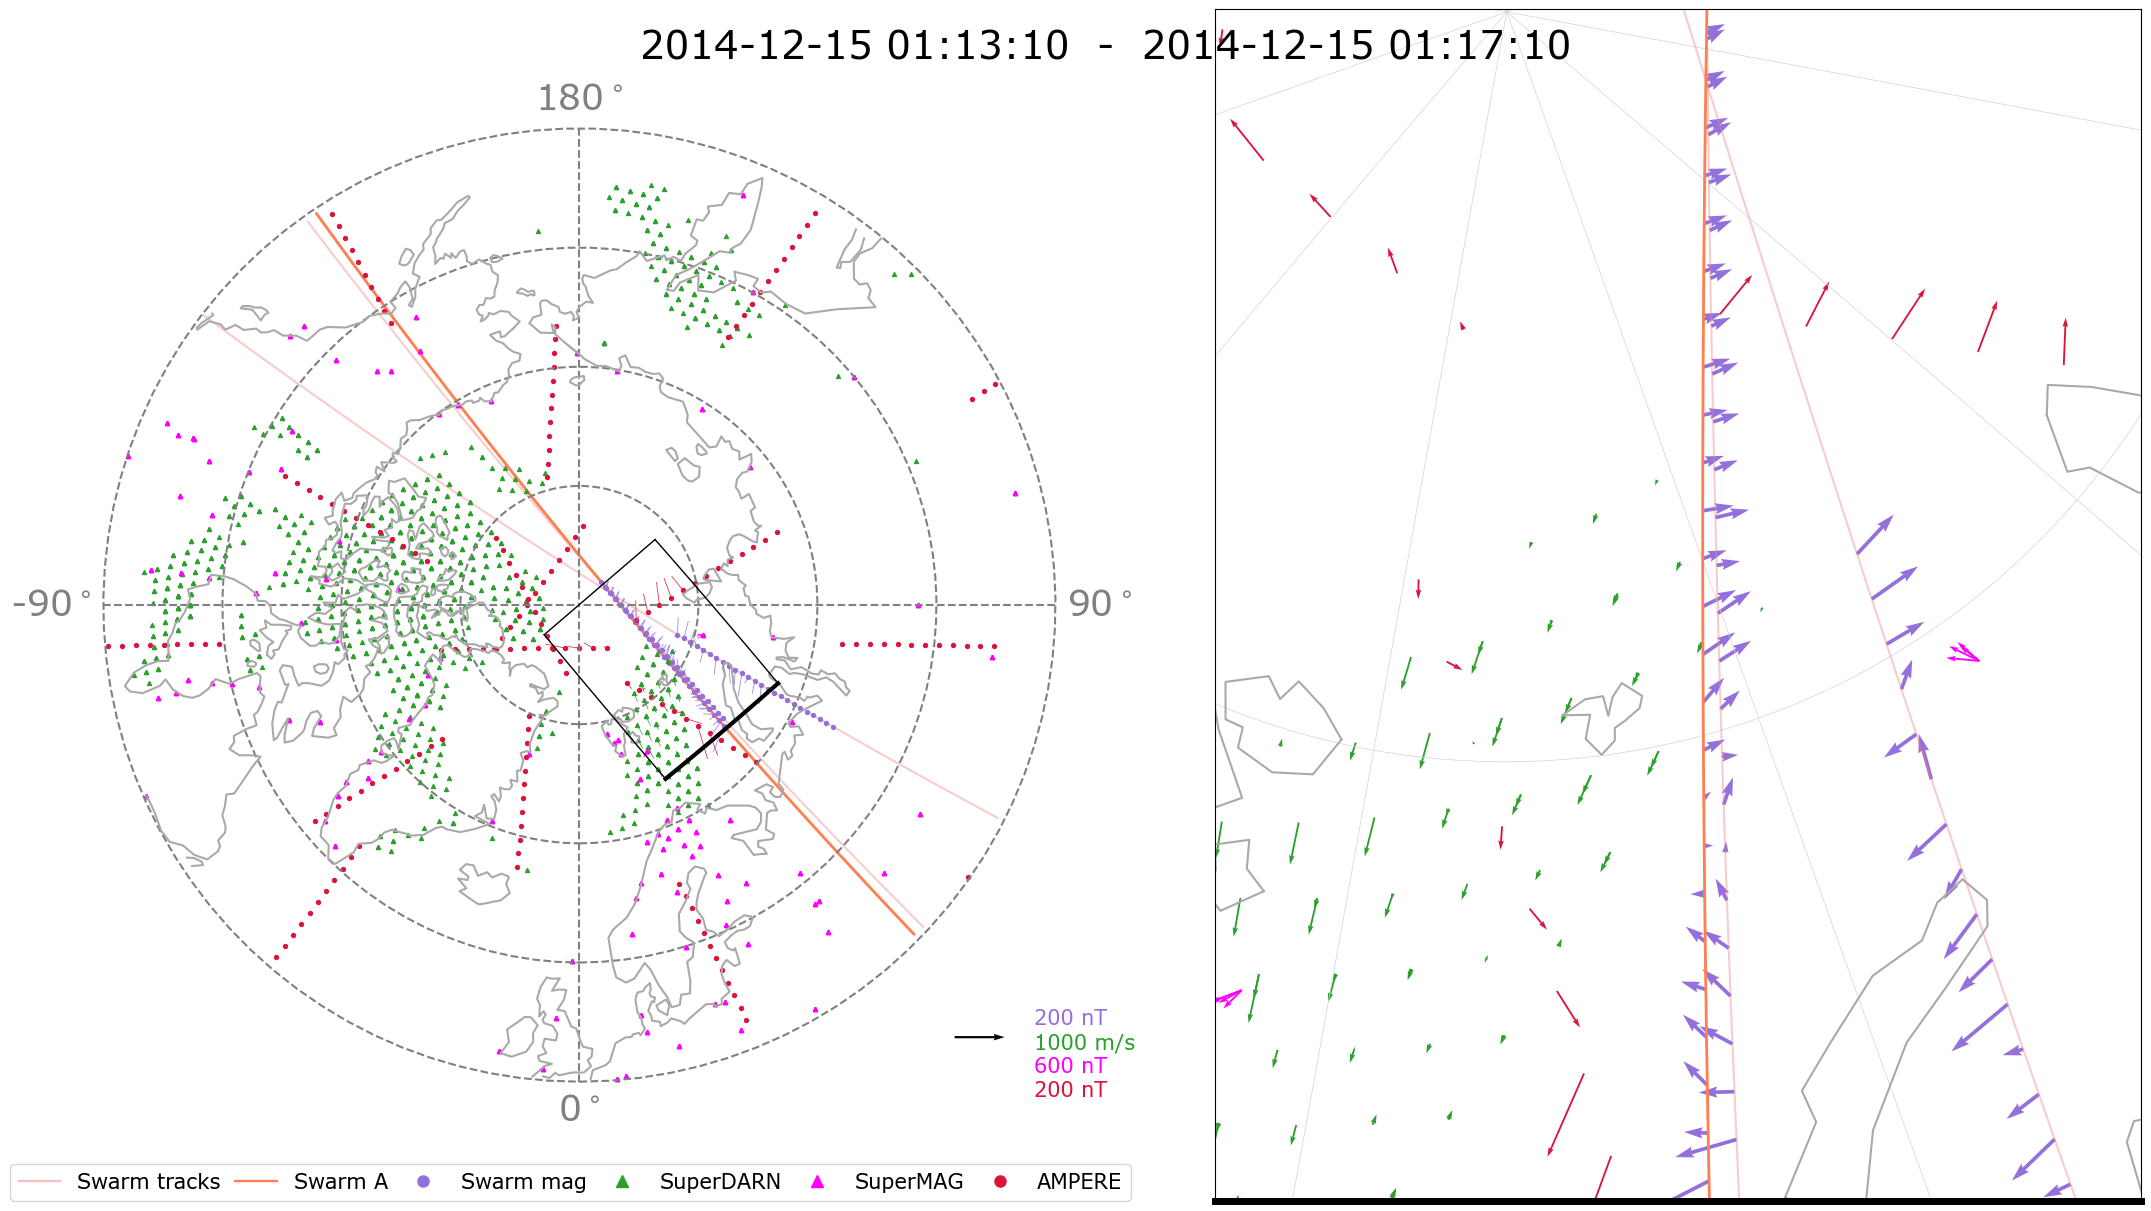

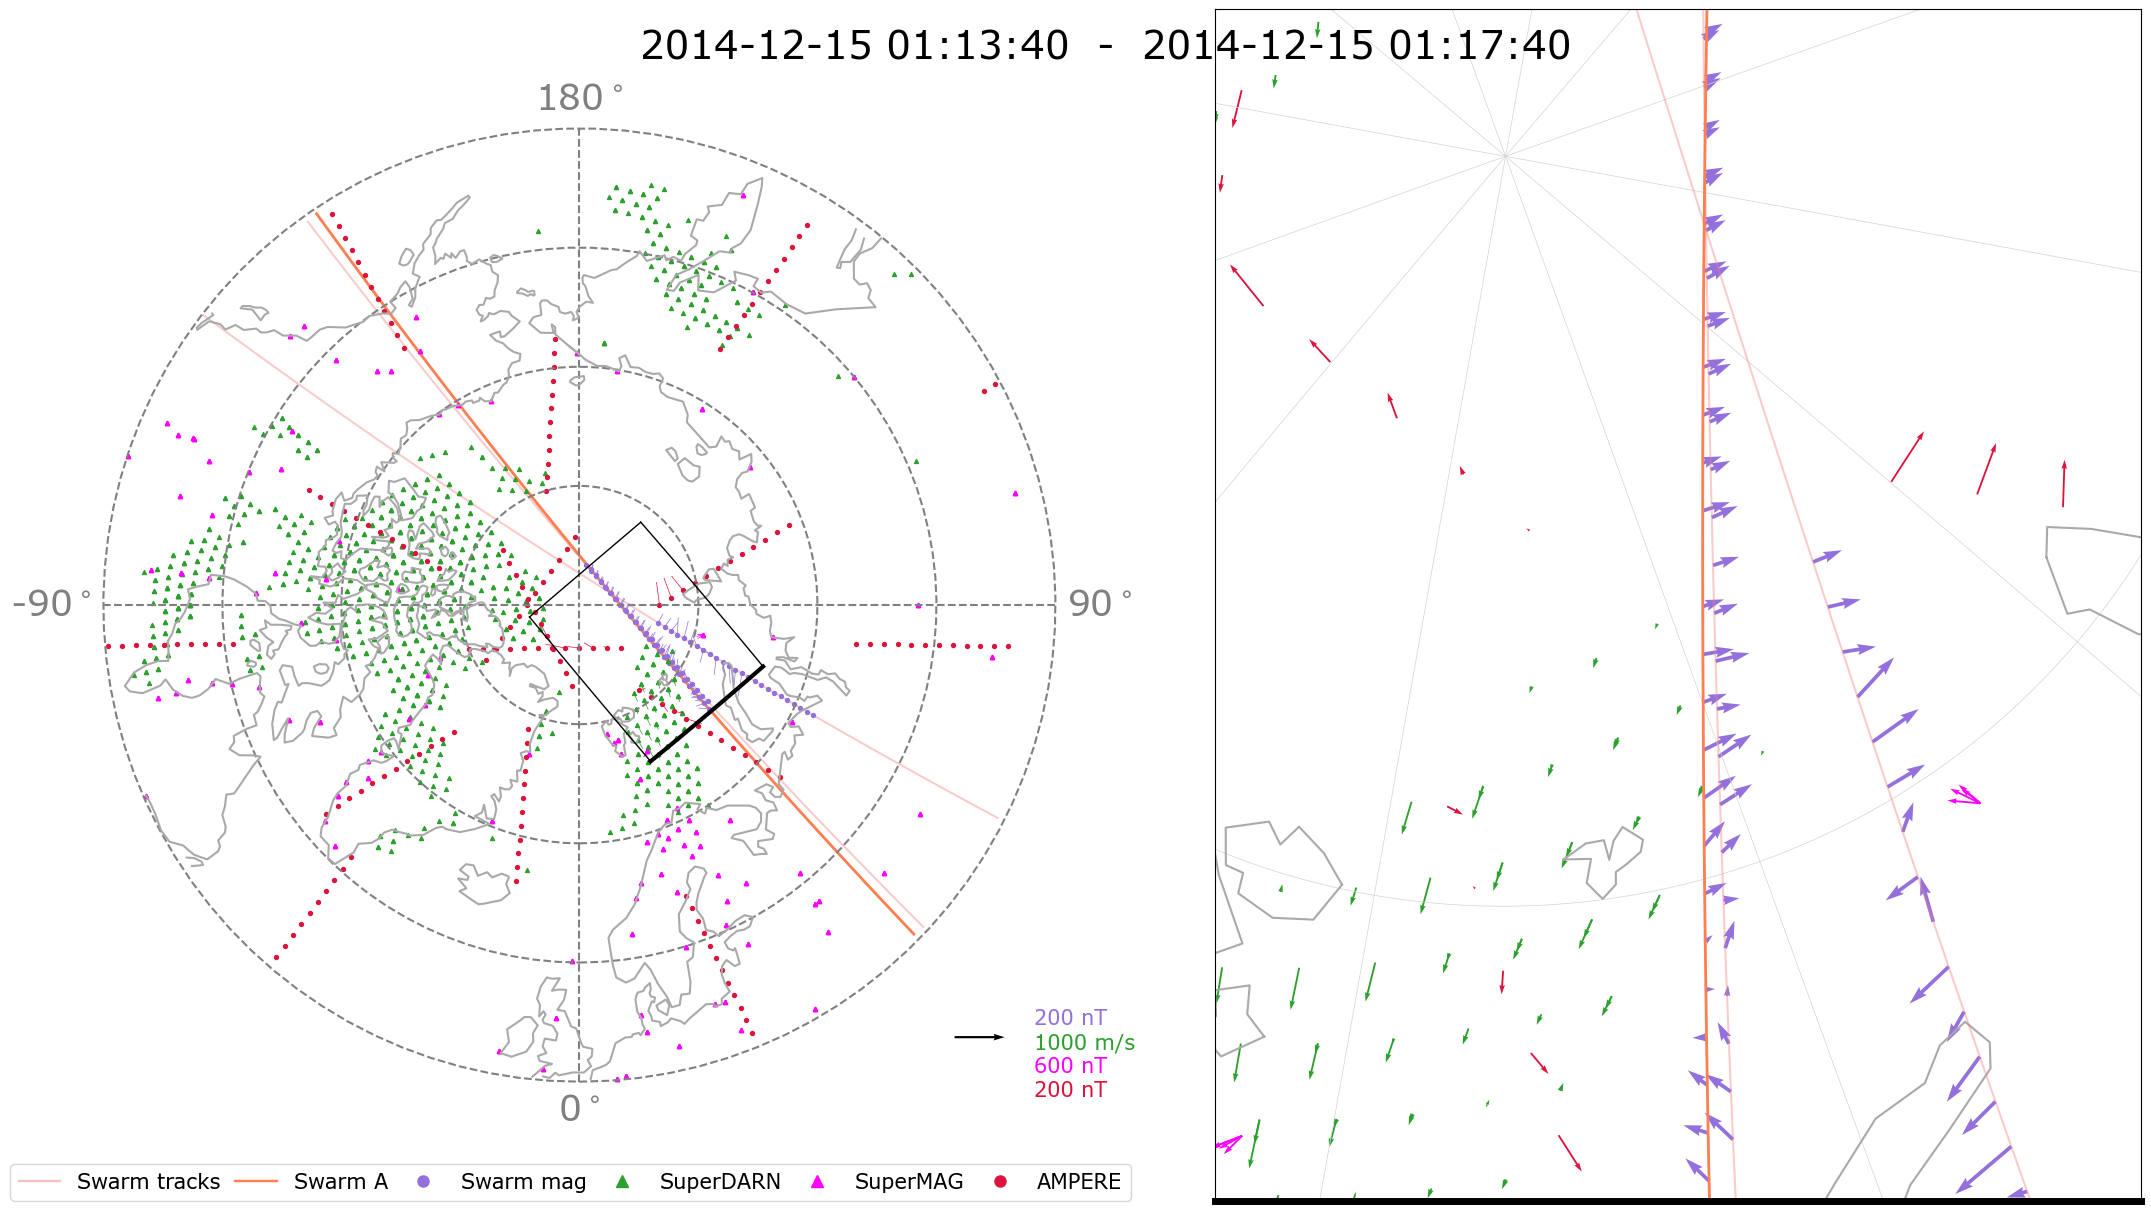

In [ ]:
input_frames = lompe_input.plot_lompe_input(grids, analysis_times, data_objects_per_grid, show_global_data=True)

input_frames[0].save(f"lompe-input_swarm{sat_id}.gif", save_all=True, append_images=input_frames[1:], duration=750, loop=0)
display(Image(filename=f'lompe-input_swarm{sat_id}.gif')) #TODO compare with the gif saved in outputs

## Run Lompe analysis

Define conductance

In [16]:
SHs, SPs = compute_conductances(conductance_method, analysis_times, grids, conductance_params)

Create Lompe Emodel, run inversion and plot reconstructed electrodynamics

In [17]:
# Regularization parameters for Lompe analysis
l1, l2 = 1, 1

lompe_models = run_lompe(analysis_times, grids, data_objects_per_grid, SHs, SPs, l1, l2)

Running Lompe analysis (l1=1.00, l2=1.00)...
space_mag_fac: Measurement uncertainty effectively changed from 3e-08 to 4.2426406871192844e-08
space_mag_fac: Measurement uncertainty effectively changed from 3e-08 to 4.2426406871192844e-08


In [18]:
lompe_models[0]['model'].data['convection'][0].values.shape

(1, 76)

In [19]:
lompe_models[0]['model']

func in plot_quiver (lompeplot) <bound method Emodel.v of <lompe.model.model.Emodel object at 0x30a48dff0>>
func in plot_quiver (lompeplot) <bound method Emodel.B_space_FAC of <lompe.model.model.Emodel object at 0x30a48dff0>>
func in plot_quiver (lompeplot) <bound method Emodel.B_ground of <lompe.model.model.Emodel object at 0x30a48dff0>>


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


func in plot_quiver (lompeplot) <bound method Emodel.j of <lompe.model.model.Emodel object at 0x30a48dff0>>
func in plot_quiver (lompeplot) <bound method Emodel.v of <lompe.model.model.Emodel object at 0x30a84d720>>
func in plot_quiver (lompeplot) <bound method Emodel.B_space_FAC of <lompe.model.model.Emodel object at 0x30a84d720>>
func in plot_quiver (lompeplot) <bound method Emodel.B_ground of <lompe.model.model.Emodel object at 0x30a84d720>>


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


func in plot_quiver (lompeplot) <bound method Emodel.j of <lompe.model.model.Emodel object at 0x30a84d720>>
Lompe output figures for each time step saved in temporary folder: /Users/margot/Docs/Academia/Research/Python/SwarmDF/src/outputs/tmp/
GIF saved in outputs directory: /Users/margot/Docs/Academia/Research/Python/SwarmDF/src/outputs/lompe-output_swarmA.gif


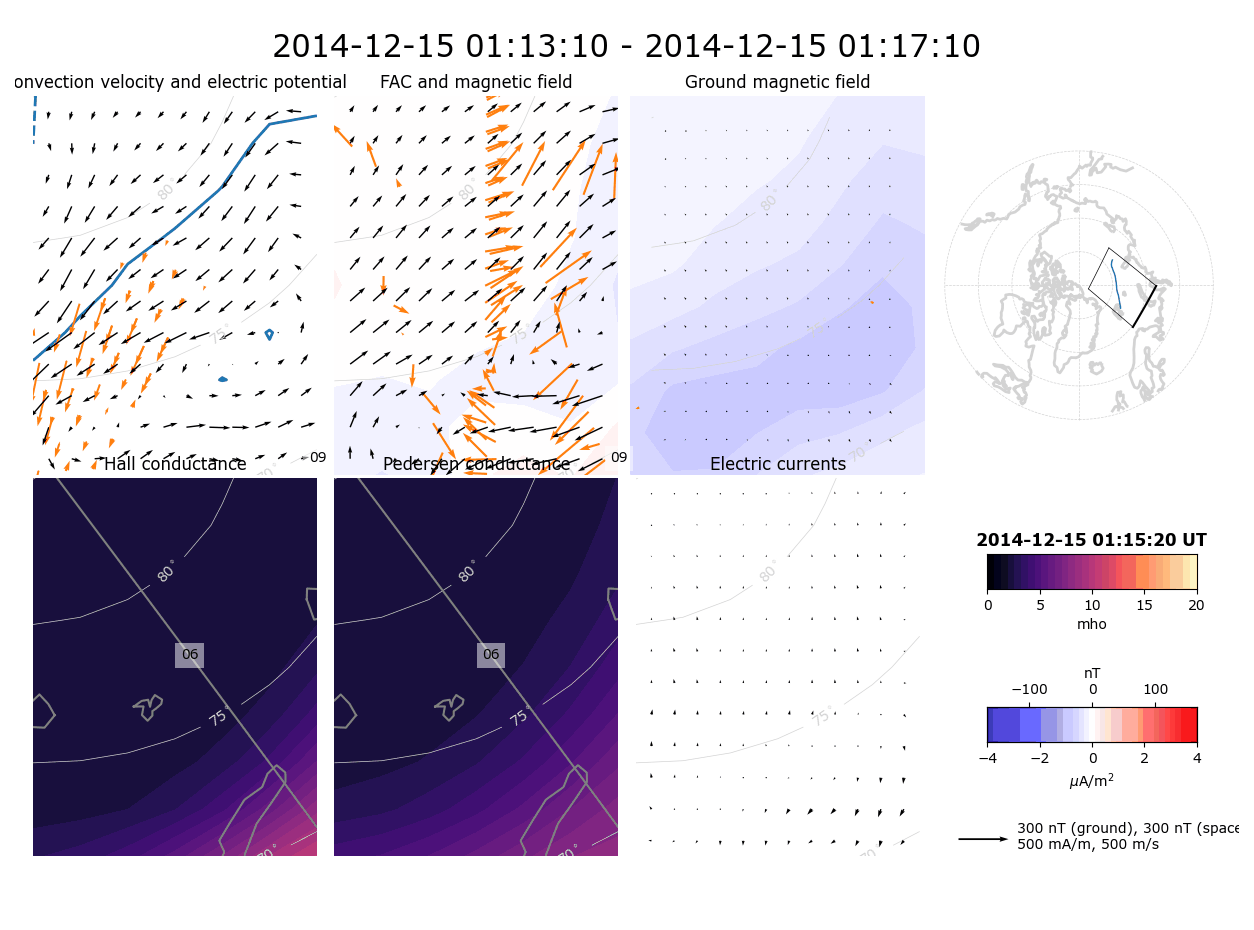

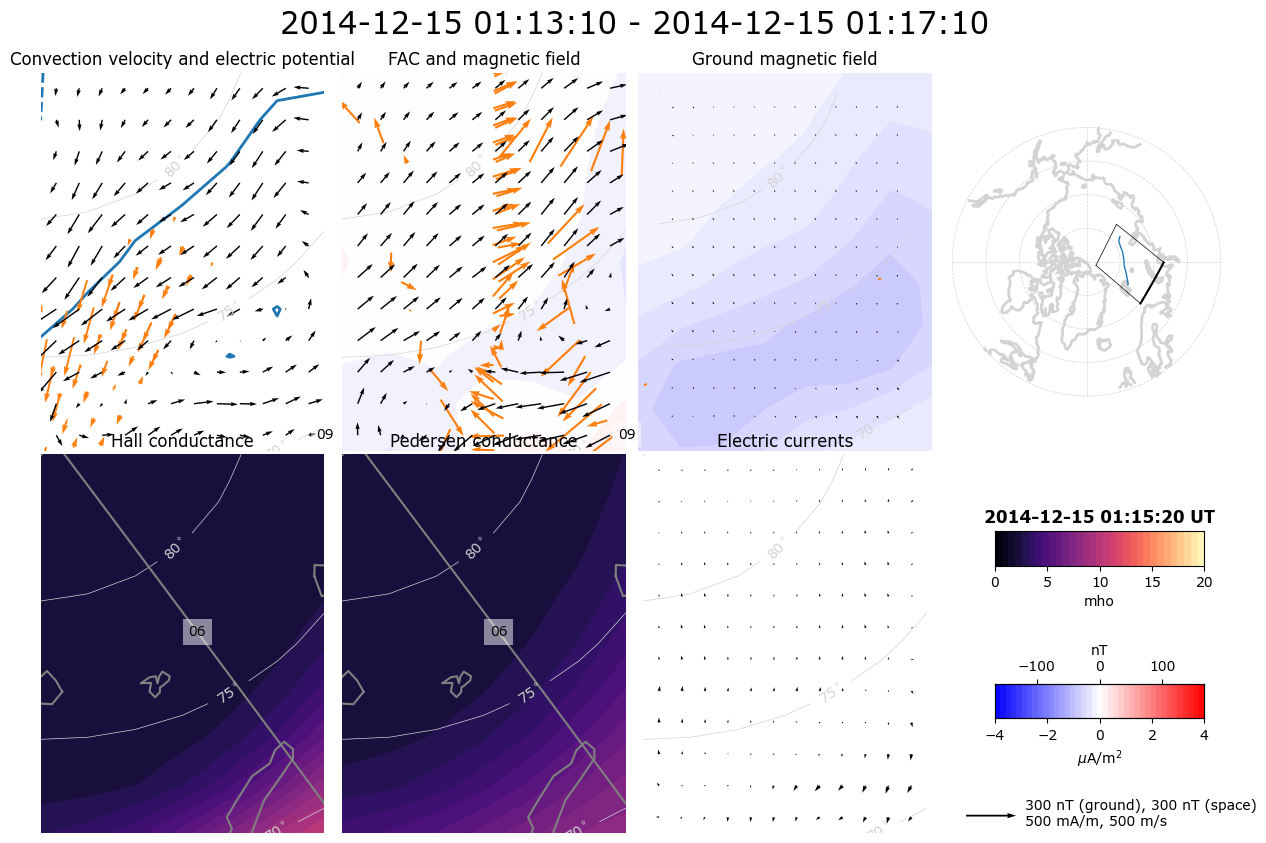

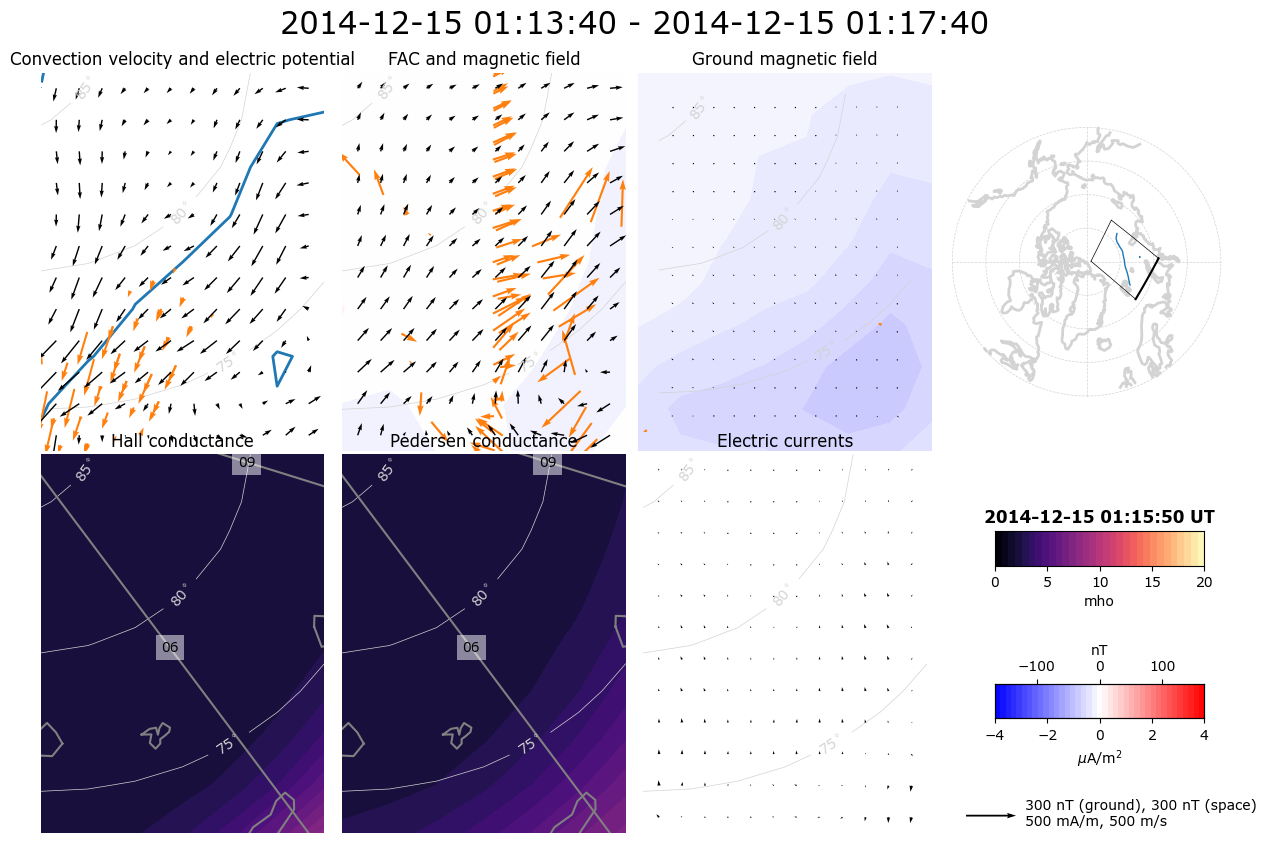

In [29]:
output_frames = plot_lompe_output(lompe_models, sat_id) 

output_frames[0].save(f"lompe-output_swarm{sat_id}.gif", save_all=True, append_images=output_frames[1:], duration=750, loop=0)
display(Image(filename=f'lompe-output_swarm{sat_id}.gif')) #TODO compare with the gif saved in outputs

In [21]:
lompe_models[0]['model'].grid_E.lat
hemi = 'NORTH' if lompe_models[0]['model'].grid_E.lat.all() > 0 else 'SOUTH'
hemi


'NORTH'

Example of what other things we can get from the lompe analysis 

In [22]:
lompe_models

[{'model': <lompe.model.model.Emodel at 0x30a48dff0>,
  't0': Timestamp('2014-12-15 01:13:10'),
  'ct': Timestamp('2014-12-15 01:15:20'),
  't1': Timestamp('2014-12-15 01:17:10'),
  'apex': apexpy.Apex(date=2014.0, refh=0, datafile='/Users/margot/anaconda3/envs/lompe-m/lib/python3.10/site-packages/apexpy/apexsh.dat', fortranlib='/Users/margot/anaconda3/envs/lompe-m/lib/python3.10/site-packages/apexpy/fortranapex.cpython-310-darwin.so'),
  'l1': 1,
  'l2': 1},
 {'model': <lompe.model.model.Emodel at 0x30a84d720>,
  't0': Timestamp('2014-12-15 01:13:40'),
  'ct': Timestamp('2014-12-15 01:15:50'),
  't1': Timestamp('2014-12-15 01:17:40'),
  'apex': apexpy.Apex(date=2014.0, refh=0, datafile='/Users/margot/anaconda3/envs/lompe-m/lib/python3.10/site-packages/apexpy/apexsh.dat', fortranlib='/Users/margot/anaconda3/envs/lompe-m/lib/python3.10/site-packages/apexpy/fortranapex.cpython-310-darwin.so'),
  'l1': 1,
  'l2': 1}]

In [23]:
# find out how to calculate joule heating (corot paper)
model1 = lompe_models[0]['model']
epot = model1.E_pot

Gamera stuff

In [24]:
time_offset=0 # gamera... 
snapshot=0 # gamera... 
lompeOSSE_models, gamera_models = run_lompeOSSE(lompe_models, time_offset, snapshot)


 Running LompeOSSE validation...
Loading Gamera data/snapshot #0
Gamera_output 0.02746333321556449
LompeOSSE 2.7457717806100845e-05

 Initializing synthetic model (2014-12-15 01:15:20)...

 Scanning user datasets and searching for corresponding Gamera data...
efield dataset not found
convection dataset found..
Getting Gamera convection data
Getting Gamera electric field
in getE gamera dipole to geo: 1.8290720423683524
in getE centered cs proj: 0.6190287908539176
griddata xi: 7.202155167236924
griddata eta: 7.100767041090876
vector cube to geo: 0.0007316670380532742
in getE interp to meas: 14.303762666881084
..Gamera convection data extracted
get_V: 16.768158042337745
ground_mag dataset found..
Getting Gamera magnetic field data
..Gamera ground_mag data extracted
get_B: 2.613265458960086
space_mag_full dataset not found
space_mag_fac dataset found..
Getting Gamera magnetic field data
..Gamera space_mag_fac data extracted
get_B: 2.619741292204708
space_mag_fac dataset found..
Getting Ga

In [25]:
# lompeOSSE_frames, gamera_frames = plot_lompeOSSE_output(lompeOSSE_models, gamera_models, gif_speed)

# lompeOSSE_frames[0].save("lompeosse.gif", save_all=True, append_images=lompeOSSE_frames[1:], duration=750, loop=0) #not necessary to save maybe? it's already saved under a different name i think
# display(Image(filename='lompeosse.gif')) #TODO compare with the gif saved in outputs

# gamera_frames[0].save("gamera.gif", save_all=True, append_images=gamera_frames[1:], duration=750, loop=0) #not necessary to save maybe? it's already saved under a different name i think
# display(Image(filename='gamera.gif')) #TODO compare with the gif saved in outputs

In [26]:
gamera_models[0]['gamera_output'].time

Timestamp('2014-12-15 01:15:20')